# Analisando Engajamento no Instagram (Parte 1) #F074

## Pergunta Fundamental

Desejamos obter respostas para a seguinte pergunta:

- Qual tipo de conteúdo gera mais engajamento na empresa?

## Base de Dados

A base de dados disponível reúne informações sobre as publicações de uma empresa desde de que ela começou a publicar no Instagram até o dia 27/mar.

## Direcionamentos do Cliente

Estes foram os direcionamentos passados pelo cliente:

- Ignore a coluna de visualizações, porque queremos entender quais variáveis contribuem para um maior número de curtidas e comentários
- Publicações sem tags realmente não possuem nenhuma tag
- A ausência de uma tag deve ser tratada como um valor vazio

## Análise da Base de Dados

### Importação de Bibliotecas

In [98]:
# Importa o numpy com o apelido np

import numpy as np

# Importa o pandas com o apelido pd
import pandas as pd

# Importa o pyplot com o apelido plt
import matplotlib.pyplot as plt

### Importação da Base de Dados

In [99]:
# Lê o arquivo especificado

df = pd.read_excel('dados-instagram.xlsx')

In [100]:
# Exibe as cinco primeiras linhas do dataframe
display(df.head())


,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,2021-09-11,2858,16,NaN,Loja,N,N,NaN,2874
1,Foto,2021-09-11,2930,28,NaN,Loja/Produtos,N,N,NaN,2958
2,Foto,2021-09-11,2807,9,NaN,Loja,N,N,NaN,2816
3,Vídeo,2021-09-12,5115,49,82878.0,Produtos,N,N,NaN,5164
4,Foto,2021-09-13,4392,45,NaN,Produtos,S,N,NaN,4437


### Remoção de Colunas Irrelevantes

In [101]:
# Remove a coluna especificada
# colunas_sem_visualizacoes = [col for col in df.columns if col != 'Visualizações']
# print(colunas_sem_visualizacoes)
# df_estatistica = df[colunas_sem_visualizacoes]
df_estatistica  = df.drop('Visualizações', axis=1)
df_estatistica = df[['Pessoas', 'Campanhas', 'Carrossel', 'Tipo', 'Tags', 'Comentários', 'Curtidas', 'Interacoes ', 'Data']]
# df_estatistica.head()





In [102]:
# Exibe as cinco primeiras linhas
df_estatistica.head()

,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
0,N,N,NaN,Foto,Loja,16,2858,2874,2021-09-11
1,N,N,NaN,Foto,Loja/Produtos,28,2930,2958,2021-09-11
2,N,N,NaN,Foto,Loja,9,2807,2816,2021-09-11
3,N,N,NaN,Vídeo,Produtos,49,5115,5164,2021-09-12
4,S,N,NaN,Foto,Produtos,45,4392,4437,2021-09-13


In [103]:
# Exibe as cinco últimas linhas
df_estatistica.tail()

,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
47,S,N,NaN,IGTV,Dicas de como usar/Novos Produtos,77,5489,5566,2022-03-12
48,S,S,NaN,Foto,Datas comemorativas/Promoções,479,29084,29563,2022-03-20
49,S,S,NaN,Foto,NaN,106,9087,9193,2022-03-22
50,S,N,NaN,Foto,NaN,186,16551,16737,2022-03-26
51,S,N,NaN,IGTV,Dicas de como usar/Produtos,65,4934,4999,2022-03-27


In [104]:
# Tamanho da base

df_estatistica.shape

(52, 9)

### Obtendo Informações sobre a Base

In [105]:
df_estatistica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Pessoas      52 non-null     object        
 1   Campanhas    52 non-null     object        
 2   Carrossel    8 non-null      object        
 3   Tipo         52 non-null     object        
 4   Tags         44 non-null     object        
 5   Comentários  52 non-null     int64         
 6   Curtidas     52 non-null     int64         
 7   Interacoes   52 non-null     int64         
 8   Data         52 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 3.8+ KB


**Observações:**

- Os tipos de dados de cada coluna estão corretos
- A coluna `Tags` possui 8 valores nulos
- A coluna `Carrossel` possui 44 valores nulos

De acordo com os direcionamentos do cliente, os 8 valores nulos da coluna `Tags` são realmente valores nulos, significando que essas publicações não receberam nenhuma tag.

Precisamos entender por que a coluna `Carrossel` está repleta de valores nulos para podermos decidir o que fazer com estes valores.

### Tratando a Base

#### Preenchendo Valores Nulos

De acordo com o resumo acima, a coluna `Carrossel` possui somente 8 valores não nulos. Vamos exibir estes valores para poder investigá-los: 

In [106]:
# Filtra a base de forma a exibir os registros não nulos da coluna Carrossel

# df_estatistica[df_estatistica['Carrossel'] == 'S']
# df_estatistica[df_estatistica['Carrossel'].isnull() == False]
# df_estatistica.Carrossel.value_counts()
# df_estatistica[df_estatistica['Carrossel'].notnull()].head()
df_estatistica.loc[df_estatistica.Carrossel.notnull()].head(10)



,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
5,N,S,S,Foto,Novos Produtos,62,5359,5421,2021-09-17
8,S,N,S,Foto,Produtos,89,6355,6444,2021-09-27
12,S,S,S,Foto,Novos Produtos,55,6166,6221,2021-10-21
21,S,N,S,Foto,Produtos,93,8328,8421,2021-12-23
25,S,N,S,Foto,Novos Produtos,138,12193,12331,2022-01-02
26,S,S,S,Foto,Datas comemorativas,354,24585,24939,2022-01-08
28,S,N,S,Foto,Novos Produtos,119,9936,10055,2022-01-15
40,S,S,S,Foto,Influenciadores,213,21621,21834,2022-02-21


In [107]:
# Filtra a base de forma a exibir somente os registros nulos da coluna Carrossel
df_estatistica[df_estatistica['Carrossel'].isnull()]

# Exibe somente as cinco primeiras linhas
# df_estatistica[df_estatistica['Carrossel'].isnull()].head()
df_estatistica.loc[df_estatistica.Carrossel.isnull()].head()


,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
0,N,N,NaN,Foto,Loja,16,2858,2874,2021-09-11
1,N,N,NaN,Foto,Loja/Produtos,28,2930,2958,2021-09-11
2,N,N,NaN,Foto,Loja,9,2807,2816,2021-09-11
3,N,N,NaN,Vídeo,Produtos,49,5115,5164,2021-09-12
4,S,N,NaN,Foto,Produtos,45,4392,4437,2021-09-13


In [108]:
# Selecionando apenas a coluna carrossel
df_estatistica.loc[df_estatistica.Carrossel.isnull(), 'Carrossel'].head()


0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Carrossel, dtype: object

**Observações:**

As publicações que eram um carrossel foram registradas com um **S**, representando um **Sim**. Portanto, as demais publicações que não eram um carrossel deveriam ter sido registradas com um **N**, representando um **Não**. Vamos corrigir isso: 

In [109]:
# # Atribui o valor N aos registros nulos da coluna Carrossel
# df_estatistica['Carrossel'].loc[df_estatistica['Carrossel'].isnull()] = 'N'
# df_estatistica.loc[df_estatistica['Carrossel'].isnull(), 'Carrossel'] = 'N'
df_estatistica.loc[df_estatistica.Carrossel.isnull(), 'Carrossel'] = 'N'

In [110]:
# Exibe as cinco primeiras linhas da base
df_estatistica.head()

,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
0,N,N,N,Foto,Loja,16,2858,2874,2021-09-11
1,N,N,N,Foto,Loja/Produtos,28,2930,2958,2021-09-11
2,N,N,N,Foto,Loja,9,2807,2816,2021-09-11
3,N,N,N,Vídeo,Produtos,49,5115,5164,2021-09-12
4,S,N,N,Foto,Produtos,45,4392,4437,2021-09-13


In [111]:
df_estatistica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Pessoas      52 non-null     object        
 1   Campanhas    52 non-null     object        
 2   Carrossel    52 non-null     object        
 3   Tipo         52 non-null     object        
 4   Tags         44 non-null     object        
 5   Comentários  52 non-null     int64         
 6   Curtidas     52 non-null     int64         
 7   Interacoes   52 non-null     int64         
 8   Data         52 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 3.8+ KB


In [112]:
df_estatistica.Carrossel.value_counts()

N    44
S     8
Name: Carrossel, dtype: int64

In [113]:
df_estatistica['Carrossel'].value_counts()

N    44
S     8
Name: Carrossel, dtype: int64

**Observações:**

Notamos que agora a coluna `Carrossel` possui 8 valores 'S' e 44 valores 'N'.

### Descrição Estatística da Base

In [114]:
# Exibe uma descrição estatística da coluna de Curtidas
# display(df_estatistica['Curtidas'].info())
# df_estatistica['Curtidas'].describe()
df_estatistica.describe()



,Comentários,Curtidas,Interacoes
count,52.000000,52.000000,52.000000
mean,189.500000,12262.730769,12452.230769
std,170.687709,8165.875326,8299.390088
min,9.000000,2807.000000,2816.000000
25%,69.500000,5492.000000,5562.500000
50%,128.000000,9603.000000,9773.500000
75%,265.250000,17621.750000,17920.750000
max,852.000000,37351.000000,37853.000000


**Obervações:**

- A média de curtidas das publicações foi de 12.262
- 50% das publicações têm até 9.603 curtidas
- A publicação com maior número de curtidas recebeu 37.351 curtidas
- A publicação com menor número de curtidas recebeu 2.807 curtidas

### Visualizando Informações

<AxesSubplot: xlabel='Data', ylabel='Comentários'>

<Figure size 2000x1200 with 0 Axes>

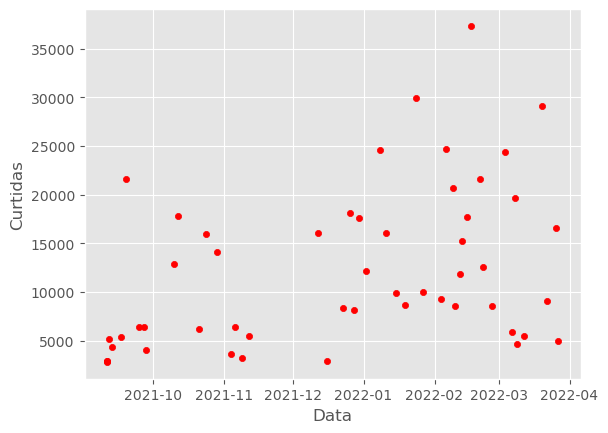

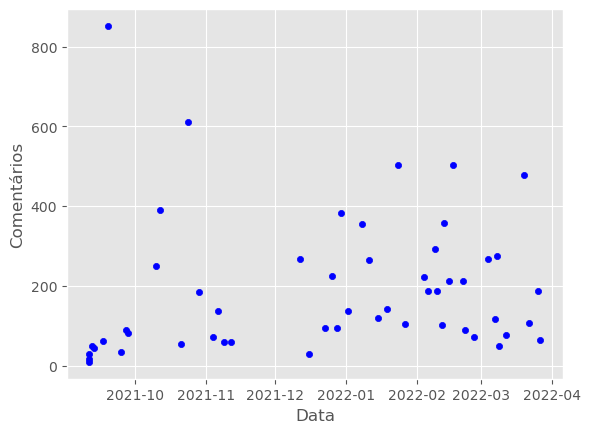

In [115]:
import matplotlib.pyplot as plt

# Define um estilo para os gráficos do matplotlib
plt.style.use("ggplot")
plt.figure(figsize = (20, 12))

# Plota um gráfico de dispersão para verificarmos uma possível correlação entre o número de curtidas e a data da publicação
# df_estatistica.info()
df_estatistica.plot.scatter(x='Data', y='Curtidas', c='red')

# Plota um gráfico de dispersão para verificarmos uma possível correlação entre o número de comentários e a data da publicação
df_estatistica.plot.scatter(x='Data', y='Comentários', c='blue')

# Exibe os gráficos


<AxesSubplot: xlabel='Data', ylabel='Comentários'>

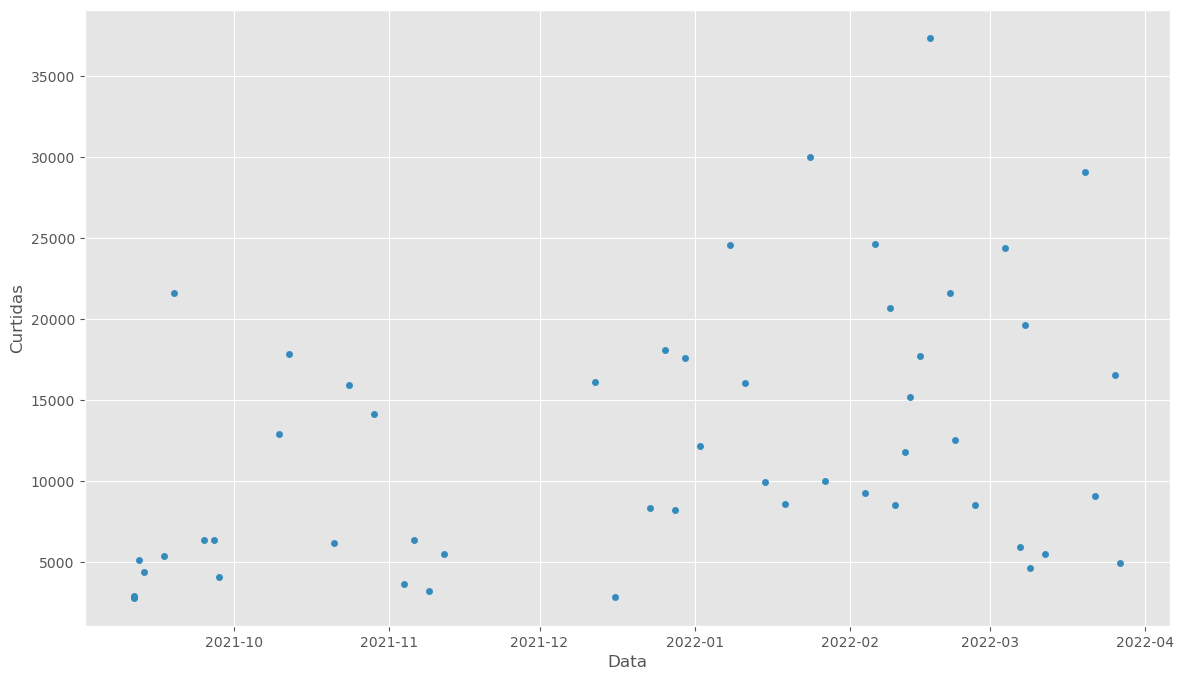

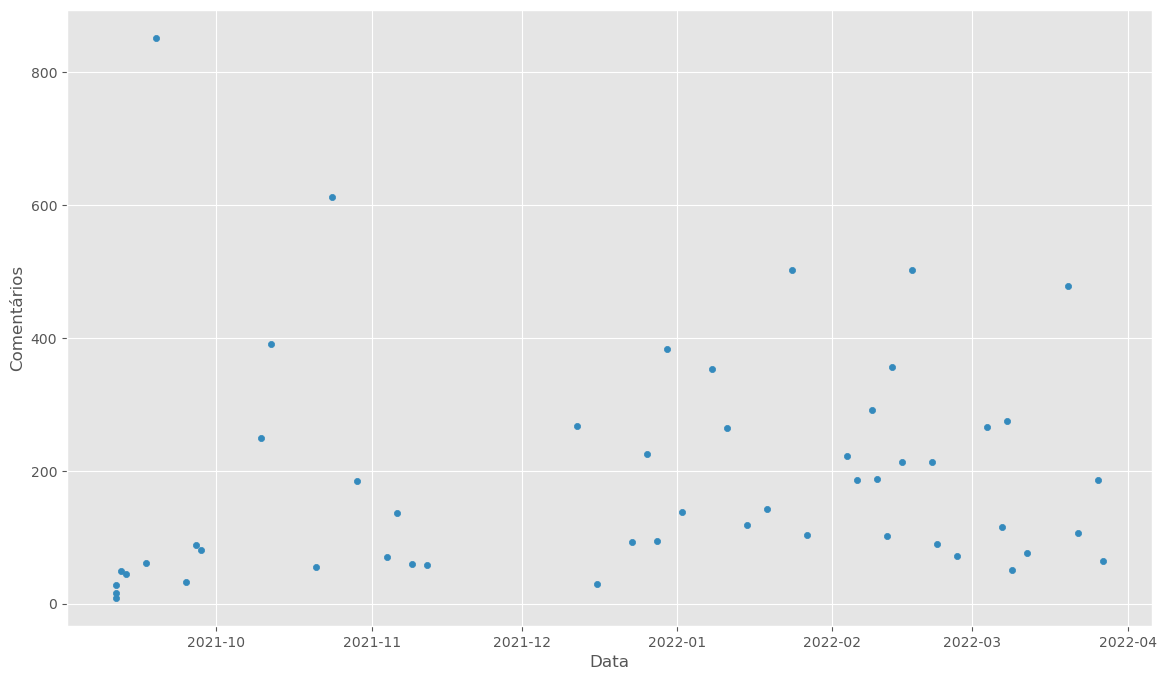

In [116]:
df_estatistica.plot(kind="scatter", x='Data', y='Curtidas', figsize=(14,8))
df_estatistica.plot(kind="scatter", x='Data', y='Comentários', figsize=(14,8))


<AxesSubplot: xlabel='Data', ylabel='Comentários'>

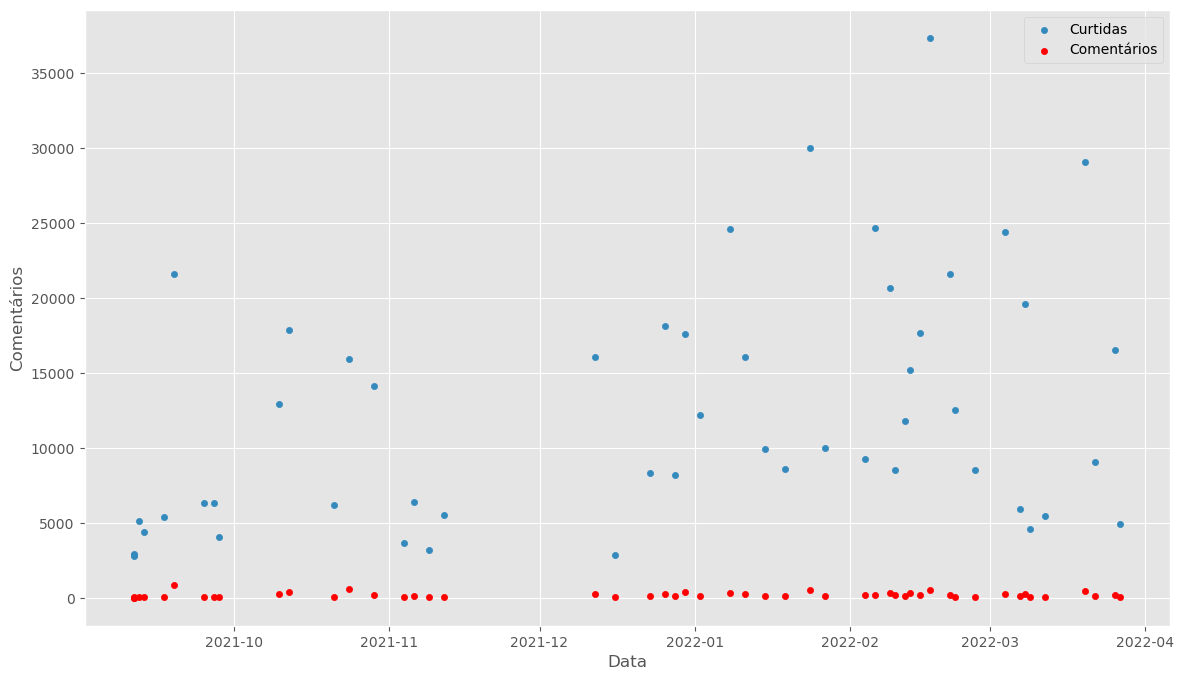

In [117]:
# Colocando 2 graficos no mesmo eixo
ax070 = df_estatistica.plot(kind="scatter", x='Data', y='Curtidas', label='Curtidas', figsize=(14,8))

df_estatistica.plot(kind="scatter", x='Data', y='Comentários', c='red', label='Comentários', figsize=(14,8), ax=ax070)


**Observações:**

Parece não haver uma correlação entre o número de curtidas e o número de comentários das publicações com a data em que elas foram feitas. 

### Ordenando a Base

#### As 5 Melhores Publicações

In [118]:
# Exibe os registros das cinco publicações que mais tiveram curtidas
# for i in df_estatistica['Curtidas'].sort_values(ascending=False).index:
    # print(df_estatistica[i])
# df_estatistica.iloc[[0,1]]
    
# df_estatistica.iloc[df_estatistica['Curtidas'].sort_values(ascending=False).index].head()
df_estatistica.sort_values(by='Curtidas', ascending=False).head()



,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
39,S,S,N,Foto,Promoções,502,37351,37853,2022-02-17
30,S,S,N,Reels,Trends,502,29981,30483,2022-01-24
48,S,S,N,Foto,Datas comemorativas/Promoções,479,29084,29563,2022-03-20
33,S,S,N,Foto,Influenciadores,186,24655,24841,2022-02-06
26,S,S,S,Foto,Datas comemorativas,354,24585,24939,2022-01-08


#### As 5 Piores Publicações

In [119]:
# Exibe os registros das cinco publicações que menos tiveram curtidas
# df_estatistica.iloc[df_estatistica['Curtidas'].sort_values(ascending=True).index].head()
# df_estatistica.sort_values(by='Curtidas', ascending=False).tail()
df_estatistica.sort_values(by='Curtidas', ascending=True).head()


,Pessoas,Campanhas,Carrossel,Tipo,Tags,Comentários,Curtidas,Interacoes,Data
2,N,N,N,Foto,Loja,9,2807,2816,2021-09-11
0,N,N,N,Foto,Loja,16,2858,2874,2021-09-11
20,N,N,N,Foto,Produtos,29,2881,2910,2021-12-16
1,N,N,N,Foto,Loja/Produtos,28,2930,2958,2021-09-11
17,N,N,N,Vídeo,Produtos,60,3213,3273,2021-11-09


**Observações:**

- Prestar atenção nos padrões das 5 primeiras linhas das base organizada por alguma coisa que eu quero maximizar
- Prestar atenção nos padrões das 5 ultimas linhas das base organizada por alguma coisa que eu quero maximizar
- Ver o que engaja com influenciadores


- Dentre as cinco publicações que mais obtiveram curtidas, todas tinham a presença de pessoas e envolviam alguma campanha
- Dentre as cinco publicações que menos obtiveram curtidas, nenhuma tinha a presença de pessoas e nenhuma envolvia alguma campanha

### Agregando Informações

In [120]:
# Configura a exibição de números decimais no pandas

# pd.options.display.float_format = '{:,.2f}'.format


#### Segmentação por Pessoas


- Aqui começamos a comprovar nossa hipotese
- É isso que um cientista faz 
    - Formula hipotese 
    - Buscar informações dos dados 
    - Achar um padrão
    - Tenta comprovar


In [ ]:
# Agrupa os dados com base na coluna de Pessoas, calculando a média de curtidas e de comentários

print('Media de comentarios com pessoas: {}'.format(df_estatistica[df_estatistica['Pessoas'] == 'S']['Comentários'].mean()))
print('Media de comentarios sem pessoas: {}'.format(df_estatistica[df_estatistica['Pessoas'] == 'N']['Comentários'].mean()))

print('Media de curtidas com pessoas: {}'.format(df_estatistica[df_estatistica['Pessoas'] == 'S']['Curtidas'].mean()))
print('Media de curtidas sem pessoas: {}'.format(df_estatistica[df_estatistica['Pessoas'] == 'N']['Curtidas'].mean()))

display(df_estatistica.groupby('Pessoas')[['Curtidas', 'Comentários']].mean())
display(df_estatistica.groupby('Pessoas')[['Curtidas', 'Comentários']].sum())




Media de comentarios com pessoas: 230.5
Media de comentarios sem pessoas: 52.833333333333336
Media de curtidas com pessoas: 14664.55
Media de curtidas sem pessoas: 4256.666666666667


,Curtidas,Comentários
Pessoas,,
N,4256.666667,52.833333
S,14664.550000,230.500000


,Curtidas,Comentários
Pessoas,,
N,51080,634
S,586582,9220


**Observação:**

Para este perfil, a média curtidas para publicações que têm pessoas é de cerca de 14.700 curtidas, enquanto que a média para publicações sem pessoa é de cerca de 4.300 curtidas. Com isso, percebemos que a média de curtidas de publicações com pessoas é cerca de 3,44 vezes a média de curtidas de publicações sem pessoas.  
Além disso, notamos que a média de comentários de publicações com pessoas é cerca de 4,4 vezes a média de comentários de publicações sem pessoas.

#### Segmentação por Pessoas e Campanhas

In [ ]:
# Agrupa os dados com base nas colunas Pessoas e Campanhas, calculando a média de curtidas e de comentários

# df_estatistica.groupby(['Pessoas', 'Campanhas'])[['Curtidas', 'Comentários']].mean()
df_estatistica.groupby(['Pessoas', 'Campanhas'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False)


Curtidas  Comentários
Pessoas Campanhas                       
S       S          19405.35        303.2
        N           9923.75        157.8
N       S           5852.50         47.5
        N           3937.50         53.9

**Observações:**

- Publicações com pessoas e com campanhas apresentam uma média de 19,4 mil curtidas
- Publicações com pessoas e sem campanhas têm uma média de quase 10 mil curtidas
- Se a publicação não tiver pessoas, sua média de curtidas será de, no máximo, 5,9 mil curtidas

Para este perfil, é evidente que a presença de pessoas em suas publicações gera um maior engajamento. Logo, a empresa deve publicar mais conteúdo que envolva pessoas.

#### Segmentação por Pessoas, Campanhas e Tipo

In [123]:
df_estatistica.groupby(['Pessoas', 'Campanhas', 'Tipo'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False)


Curtidas  Comentários
Pessoas Campanhas Tipo                            
S       S         Reels  24801.000000   388.500000
                  Foto   19105.375000   284.187500
                  Vídeo  16409.500000   370.000000
        N         Reels  12894.000000   249.000000
                  Foto   10815.285714   159.928571
                  IGTV    6833.400000   133.600000
N       N         Reels   5934.500000    98.000000
        S         Foto    5852.500000    47.500000
        N         Vídeo   4007.500000    65.250000
                  Foto    2869.000000    20.500000

**Observações:**

A média de curtidas para todos os tipos de publicações que envolviam pessoas ficou acima de 10 mil, exceto para o IGTV. Já as publicações que não envolviam pessoas tiveram uma média de curtidas abaixo de 6 mil.

**Observações:**

O perfil só publicou dois vídeos com pessoas e campanhas. Os demais vídeos não tinham pessoas e não eram vídeos de campanhas. Estes últimos apresentaram baixo desempenho.

Para obtermos mais insights, a empresa poderia fazer um experimento no qual ela publicaria vídeos com pessoas e sem envolver nenhuma campanha e vídeos sem pessoas mas envolvendo uma campanha. 

#### Segmentação por Carrossel

In [124]:
df_estatistica.groupby(['Carrossel'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False)


,Curtidas,Comentários
Carrossel,,
N,12343.613636,198.431818
S,11817.875000,140.375000


**Observações:**

Notamos que publicações que são carrossel não são tão relevantes para o engajamento com as publicações deste perfil.

## Conclusões

Com a análise realizada, chegamos as seguintes conclusões para o perfil de nosso cliente:

- Publicações que envolvem pessoas engajam muito mais do que publicações que não contam com a presença de pessoas
- Publicações que envolvem alguma campanha da empresa apresentam melhor engajamento
- O carrossel não foi um diferencial para melhorar o engajamento

# Observações finais 079

- Observar o que ta puxando a media para baixo

In [177]:
display(type(df_estatistica.groupby(['Campanhas'])[['Curtidas', 'Comentários']]))
print('Media')
display(df_estatistica.groupby(['Campanhas'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False))
print('Soma')
display(df_estatistica.groupby(['Campanhas'])[['Curtidas', 'Comentários']].sum().sort_values(by='Curtidas', ascending=False))

print('Media')
display(df_estatistica.groupby(['Campanhas', 'Pessoas'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False))
print('Soma')
display(df_estatistica.groupby(['Campanhas', 'Pessoas'])[['Curtidas', 'Comentários']].sum().sort_values(by='Curtidas', ascending=False))


print('Media')
display(df_estatistica.groupby(['Campanhas', 'Pessoas', 'Tipo'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False))
print('Soma')
display(df_estatistica.groupby(['Campanhas', 'Pessoas', 'Tipo'])[['Curtidas', 'Comentários']].sum().sort_values(by='Curtidas', ascending=False))



pandas.core.groupby.generic.DataFrameGroupBy

Media


,Curtidas,Comentários
Campanhas,,
S,18173.272727,279.954545
N,7928.333333,123.166667


Soma


,Curtidas,Comentários
Campanhas,,
S,399812,6159
N,237850,3695


...

Curtidas  Comentários
Campanhas Pessoas                       
S         S          388107         6064
N         S          198475         3156
          N           39375          539
S         N           11705           95

Media


Curtidas  Comentários
Campanhas Pessoas Tipo                            
S         S       Reels  24801.000000   388.500000
                  Foto   19105.375000   284.187500
                  Vídeo  16409.500000   370.000000
N         S       Reels  12894.000000   249.000000
                  Foto   10815.285714   159.928571
                  IGTV    6833.400000   133.600000
          N       Reels   5934.500000    98.000000
S         N       Foto    5852.500000    47.500000
N         N       Vídeo   4007.500000    65.250000
                  Foto    2869.000000    20.500000

Soma


Curtidas  Comentários
Campanhas Pessoas Tipo                        
S         S       Foto     305686         4547
N         S       Foto     151414         2239
S         S       Reels     49602          777
N         S       IGTV      34167          668
S         S       Vídeo     32819          740
N         N       Vídeo     16030          261
          S       Reels     12894          249
          N       Reels     11869          196
S         N       Foto      11705           95
N         N       Foto      11476           82

In [173]:
# display(df_estatistica.groupby(['Tipo'])[['Curtidas', 'Comentários']].mean().sort_values(by='Curtidas', ascending=False))
mean_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'S')]['Curtidas'].mean()
mean_Not_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'N')]['Curtidas'].mean()

print('Postagens com pessoas tem uma media de {} vezes mais curtidas'.format(mean_Pessoas/mean_Not_Pessoas))

mean_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'S') & (df_estatistica.Tipo == 'Reels')]['Curtidas'].mean()
mean_Not_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'N') & (df_estatistica.Tipo == 'Reels')]['Curtidas'].mean()

print('Reels com pessoas tem uma media de {} vezes mais curtidas'.format(mean_Pessoas/mean_Not_Pessoas))

mean_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'S') & (df_estatistica.Tipo == 'Foto')]['Curtidas'].mean()
mean_Not_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'N') & (df_estatistica.Tipo == 'Foto')]['Curtidas'].mean()

print('Fotos com pessoas tem uma media de {} vezes mais curtidas'.format(mean_Pessoas/mean_Not_Pessoas))

mean_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'S') & (df_estatistica.Tipo == 'Vídeo')]['Curtidas'].mean()
mean_Not_Pessoas = df_estatistica[(df_estatistica.Tipo != 'IGTV') & (df_estatistica.Pessoas == 'N') & (df_estatistica.Tipo == 'Vídeo')]['Curtidas'].mean()

print('Fotos com pessoas tem uma media de {} vezes mais curtidas'.format(mean_Pessoas/mean_Not_Pessoas))

Postagens com pessoas tem uma media de 3.707897975165007 vezes mais curtidas
Reels com pessoas tem uma media de 3.510321004296908 vezes mais curtidas
Fotos com pessoas tem uma media de 3.9437470342090504 vezes mais curtidas
Fotos com pessoas tem uma media de 4.094697442295695 vezes mais curtidas
